# Random Forest Model

Random Forest combines many decision trees and lets them vote on the final crop. This is the model we will deploy in the application because it gives strong predictions and also provides feature importance.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
os.makedirs("../outputs", exist_ok=True)

from sklearn.ensemble import RandomForestClassifier
import joblib

## Load and Split the Dataset

We use the same 60/20/20 split as the other three models.

In [2]:
df = pd.read_csv("../Dataset/Crop_recommendation_dataset.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]
y = df["label"]

# First keep 20% aside for the final test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 25% of the remaining 80% gives 20% of the full dataset for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1320, 7)
Validation set: (440, 7)
Test set: (440, 7)


## Choose Simple Random Forest Settings

We test a small number of settings on the validation set. Random Forest does not need feature scaling.

In [3]:
settings = []
for n_estimators in [100, 200]:
    for max_depth in [None, 10, 20]:
        for min_samples_leaf in [1, 2]:
            settings.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf
            })

val_accuracies = []
for setting in settings:
    model = RandomForestClassifier(
        n_estimators=setting["n_estimators"],
        max_depth=setting["max_depth"],
        min_samples_leaf=setting["min_samples_leaf"],
        random_state=42
    )
    model.fit(X_train, y_train)
    val_accuracy = accuracy_score(y_val, model.predict(X_val))
    val_accuracies.append(val_accuracy)
    print(setting, "->", f"Validation Accuracy: {val_accuracy:.4f}")

best_index = val_accuracies.index(max(val_accuracies))
best_setting = settings[best_index]
print("\nSelected settings:", best_setting)
print(f"Best validation accuracy: {max(val_accuracies):.4f}")

{'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9909


{'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9886


{'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9909
{'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9886


{'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9909
{'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9886


{'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9932


{'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9909


{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9886


{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9886


{'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9932


{'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9909

Selected settings: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
Best validation accuracy: 0.9932


## Train the Final Random Forest

After validation selects the best Random Forest settings, we combine training and validation. The final model is trained on 80% of the dataset while the test set remains untouched for final evaluation.


In [4]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

rf_model = RandomForestClassifier(n_estimators=best_setting["n_estimators"], max_depth=best_setting["max_depth"], min_samples_leaf=best_setting["min_samples_leaf"], random_state=42)
rf_model.fit(X_train_final, y_train_final)

print("Final training set:", X_train_final.shape)
print("Final test set:", X_test.shape)


Final training set: (1760, 7)
Final test set: (440, 7)


## Final Test Evaluation

We now use the untouched test set for the final Random Forest evaluation.

In [5]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Random Forest Final Test Statistics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Final Test Statistics
Accuracy:  0.9932
Precision: 0.9935
Recall:    0.9932
F1-score:  0.9932

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   

## Feature Importance

Feature importance tells us which inputs played a larger role across the trees. It helps us explain the model at a general level.

rainfall       0.221086
humidity       0.214166
K              0.178466
P              0.148343
N              0.104770
temperature    0.079668
ph             0.053500
dtype: float64


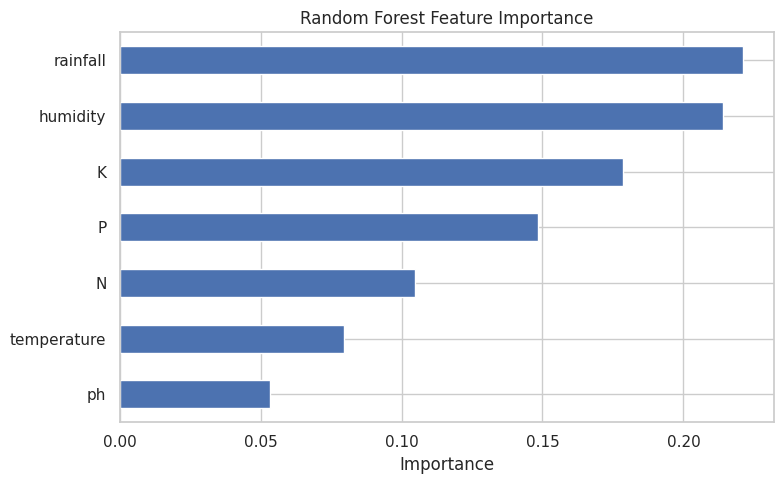

In [6]:
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importance)
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/random_forest_feature_importance.png", dpi=220, bbox_inches="tight")
plt.show()

## Confusion Matrix

The confusion matrix shows where the Random Forest made correct and incorrect crop predictions on the test set.

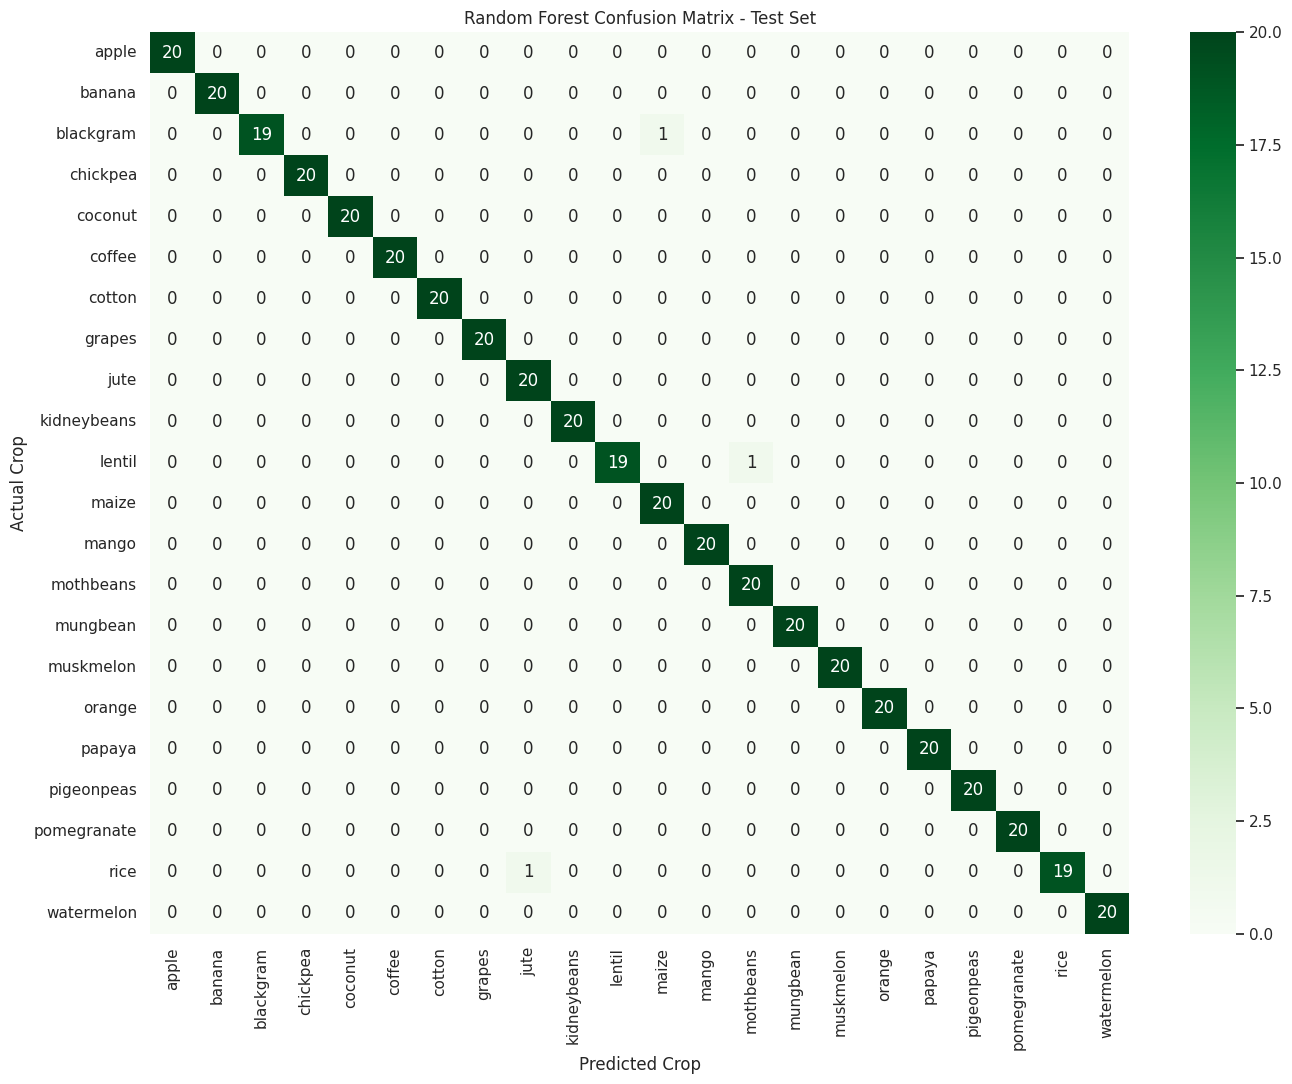

In [7]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes)
plt.title("Random Forest Confusion Matrix - Test Set")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/random_forest_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## Save the Deployment Model

The final Random Forest, trained on the combined training and validation data, is saved so the Flask application can load the same trained model directly.


In [8]:
os.makedirs("../model", exist_ok=True)
joblib.dump(rf_model, "../model/random_forest_model.pkl")
print("Random Forest model saved successfully: ../model/random_forest_model.pkl")


Random Forest model saved successfully: ../model/random_forest_model.pkl


## Findings

Random Forest gives very strong performance on the final test set and also provides feature importance. We will compare it fairly with the other models before making the final conclusion.